# Analysis finops

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
cost_by_user = pd.read_csv("/home/tatiane/repositorios/finops-data-cost-monitoring/data/analysis/cost_by_user.csv")
anomalies = pd.read_csv("/home/tatiane/repositorios/finops-data-cost-monitoring/data/analysis/anomalies.csv")

cost_by_user.head()

,user_id,total_cost
0,33,543.65260
1,192,489.14950
2,163,438.48395
3,102,426.59715
4,108,418.17060


In [3]:
# Usuários mais caros
top_users = cost_by_user.sort_values(by='total_cost', ascending=False).head(10)
top_users

,user_id,total_cost
0,33,543.652600
1,192,489.149500
2,163,438.483950
3,102,426.597150
4,108,418.170600
5,197,410.498075
6,172,403.541500
7,115,398.889900
8,131,397.891350
9,183,386.710600


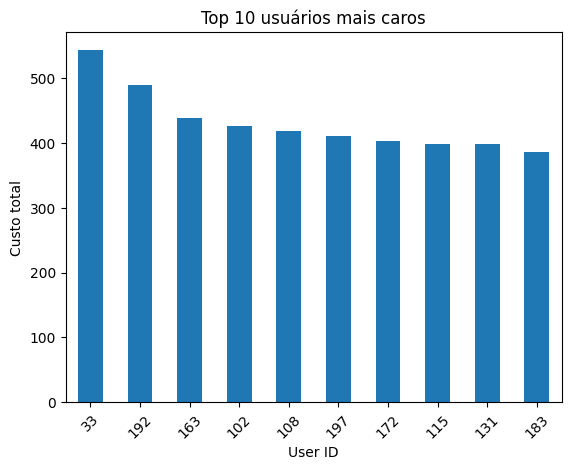

In [4]:
# Visualização
plt.figure()
top_users.set_index('user_id')['total_cost'].plot(kind='bar')

plt.title("Top 10 usuários mais caros")
plt.xlabel("User ID")
plt.ylabel("Custo total")

plt.xticks(rotation=45)
plt.show()

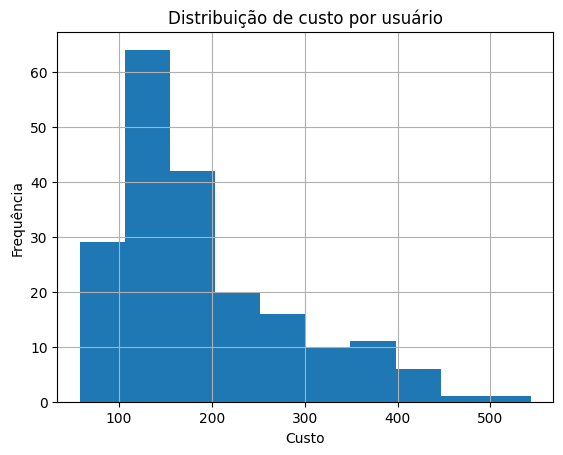

In [5]:
# Distribuição de custos
plt.figure()
cost_by_user['total_cost'].hist()

plt.title("Distribuição de custo por usuário")
plt.xlabel("Custo")
plt.ylabel("Frequência")

plt.show()

In [6]:
# Análise de anomalias
anomalies.head()

,user_id,job_id,compute_hours,storage_gb,queries_run,date,cloud_provider,region,profile,job_type,...,usage_intensity,compute_cost,storage_cost,query_cost,region_mult,instance_mult,discount,total_cost,cost_per_query,z_score
0,104,job_49,21.70,589.32,1060,2026-01-03,aws,us-east-1,high,streaming,...,high,19.5300,11.7864,1.060,1.0,2.0,0.9,32.3764,0.030544,4.034724
1,186,job_49,19.63,479.45,938,2026-01-03,aws,us-west-2,high,streaming,...,high,19.4337,9.5890,0.938,1.1,2.0,0.9,29.9607,0.031941,3.631883
2,86,job_16,35.98,123.30,1276,2026-01-04,azure,sa-east-1,high,streaming,...,high,38.8584,2.4660,1.276,1.2,2.0,0.9,42.6004,0.033386,5.739673
3,183,job_36,34.07,715.20,922,2026-01-04,azure,us-east-1,high,ad-hoc,...,high,15.3315,14.3040,0.922,1.0,1.0,0.9,30.5575,0.033143,3.731405
4,115,job_7,12.07,733.62,1804,2026-01-07,aws,sa-east-1,high,ad-hoc,...,high,9.7767,14.6724,1.804,1.2,1.5,0.9,26.2531,0.014553,3.013605


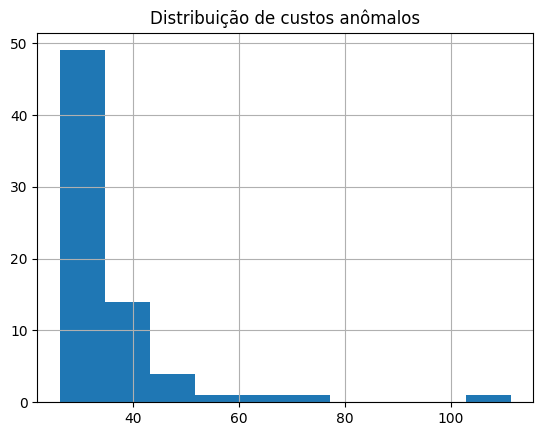

In [7]:
# Visualizar magnitude
plt.figure()
anomalies['total_cost'].hist()

plt.title("Distribuição de custos anômalos")
plt.show()

In [8]:
# Principais anomalias
top_anomalies = anomalies.sort_values(by='total_cost', ascending=False).head(10)
top_anomalies

,user_id,job_id,compute_hours,storage_gb,queries_run,date,cloud_provider,region,profile,job_type,...,usage_intensity,compute_cost,storage_cost,query_cost,region_mult,instance_mult,discount,total_cost,cost_per_query,z_score
10,163,job_23,99.31,561.75,1776,2026-01-15,azure,us-west-2,high,batch,...,high,98.31690,11.2350,1.776,1.1,2.0,0.9,111.32790,0.062685,17.200636
37,114,job_34,60.29,718.96,650,2026-02-13,gcp,us-west-2,high,ad-hoc,...,high,59.68710,14.3792,0.650,1.1,2.0,0.9,74.71630,0.114948,11.095304
28,160,job_16,54.27,559.48,1012,2026-02-05,gcp,us-east-1,high,streaming,...,high,48.84300,11.1896,1.012,1.0,2.0,0.9,61.04460,0.060321,8.815418
48,188,job_20,63.56,380.59,1624,2026-03-01,gcp,us-west-2,high,streaming,...,high,47.19330,7.6118,1.624,1.1,1.5,0.9,56.42910,0.034747,8.045740
55,33,job_13,36.68,737.79,1480,2026-03-10,azure,sa-east-1,high,streaming,...,high,29.71080,14.7558,1.480,1.2,1.5,0.9,45.94660,0.031045,6.297683
38,131,job_7,45.27,624.45,422,2026-02-15,gcp,us-east-1,high,ad-hoc,...,high,30.55725,12.4890,0.422,1.0,1.5,0.9,43.46825,0.103005,5.884395
36,192,job_47,34.42,678.43,1920,2026-02-12,azure,sa-east-1,high,streaming,...,high,27.88020,13.5686,1.920,1.2,1.5,0.9,43.36880,0.022588,5.867811
57,108,job_33,35.09,714.42,582,2026-03-12,gcp,sa-east-1,high,streaming,...,high,28.42290,14.2884,0.582,1.2,1.5,0.9,43.29330,0.074387,5.855220
2,86,job_16,35.98,123.30,1276,2026-01-04,azure,sa-east-1,high,streaming,...,high,38.85840,2.4660,1.276,1.2,2.0,0.9,42.60040,0.033386,5.739673
19,33,job_19,37.93,11.29,798,2026-01-20,azure,sa-east-1,high,ad-hoc,...,high,40.96440,0.2258,0.798,1.2,2.0,0.9,41.98820,0.052617,5.637583


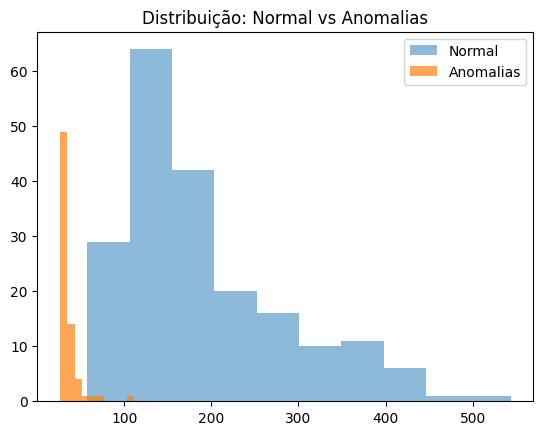

In [9]:
# Comparação geral vs anomalias
plt.figure()

plt.hist(cost_by_user['total_cost'], alpha=0.5, label='Normal')
plt.hist(anomalies['total_cost'], alpha=0.7, label='Anomalias')

plt.legend()
plt.title("Distribuição: Normal vs Anomalias")

plt.show()

In [10]:
# Percentual dos top 10
top_10_cost = top_users['total_cost'].sum()
total_cost = cost_by_user['total_cost'].sum()

print(f"Top 10 representam {100 * top_10_cost / total_cost:.2f}% do custo total")

Top 10 representam 11.30% do custo total
